In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from qbstyles import mpl_style
# mpl_style(dark=False)

# Non-linear pendulum

In [2]:
def my_evolution_step(A, input_state_unnormalized):
    num_qubits = int(np.log2(A.shape[0]))
    if not (2**num_qubits == A.shape[0]):
        raise ValueError("The dimension of matrix A is not a power of 2.")

    dev = qml.device("default.qubit", wires=num_qubits)

    norm = np.linalg.norm(input_state_unnormalized)
    
    if norm == 0:
        return input_state_unnormalized
        
    initial_state_normalized = input_state_unnormalized / norm

    @qml.qnode(dev)
    def circuit():
        qml.StatePrep(initial_state_normalized, wires=range(num_qubits))
        qml.QubitUnitary(A, wires=range(num_qubits))
        return qml.state()

    output_state = circuit()
    
    final_state = output_state * norm

    return final_state


In [3]:
# def my_circuit(A, input_state_unnormalized):
#     """
#     Este QNode define la estructura del circuito que quieres visualizar.
#     """
#     num_qubits = int(3)

#     # Normalizar el vector de estado
#     norm = np.linalg.norm(input_state_unnormalized)
#     initial_state_normalized = input_state_unnormalized / norm

#     qml.StatePrep(initial_state_normalized, wires=range(num_qubits))
#     qml.QubitUnitary(A, wires=range(num_qubits))
    
#     return qml.state()

# A = np.array([[1, 1, 0, 0, 0, 0, 0, 0],
#               [1*1, 1-1, 0, -1*1, 0, 0, 0, 0],
#               [0, 0, 1-1, 0, 1, 0, 0, 0],
#               [0, 0, 0, 1, 0, 0, 0, 0],
#               [0, 0, 0, 0, 1, 0, 0, 0],
#               [0, 0, 0, 0, 0, 1, 0, 0],
#               [0, 0, 0, 0, 0, 0, 1, 0],
#               [0, 0, 0, 0, 0, 0, 0, 1]])

# current_state_vector = np.array([1, 1, 1, 1*1, 1*1, 1, 1, 1])

In [4]:
# fig, ax = qml.draw_mpl(my_circuit, style='pennylane')(A, current_state_vector)

# # Eliminar los ticks del gráfico
# ax.set_xticks([])
# ax.set_yticks([])

# ax.grid(False)

# plt.show()

In [5]:
# --- Parameters and Constant Definitions ---
h = 0.001
omega2 = 9.8

theta0 = np.pi/2
omega0 = 2

t_final = 10
num_steps = int(t_final / h)
t_values = np.linspace(0, t_final, num_steps + 1)

# Define the gate matrix A
A = np.array([[1, h, 0, 0],
              [0, 1, -h*omega2, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])


# Define the initial state 
current_state_vector = np.array([theta0, omega0, np.sin(theta0), 1], requires_grad=False)

# List to store the output state
output_components_history = []
output_components_history.append(np.real(current_state_vector[:2]))

print(f"Starting simulation of {num_steps} iterations...\n")

for i in range(num_steps):
    # 1. Execute the circuit with the current state
    output_state_vector = my_evolution_step(A, current_state_vector)

    # 2. Update the third component with the sine of the first
    # A new state vector is created based on the output state
    next_state_vector = np.copy(output_state_vector)
    next_state_vector[2] = np.sin(np.real(next_state_vector[0]))

    # 3. Store the first 2 components 
    output_components = np.real(output_state_vector[:2]) / np.real(output_state_vector[3])
    output_components_history.append(output_components)

    # 4. Update the output state to be the input for the next circuit
    current_state_vector = next_state_vector

    print(f"--- Iteration {i+1} ---")

    # print(f"Estado de salida del circuito: {output_state_vector}")
    # print(f"Estado de entrada para el próximo paso: {current_state_vector}")
    # print(f"Componentes guardadas en el historial: {output_components}")
    # print("-" * 20)


Starting simulation of 10000 iterations...

--- Iteration 1 ---
--- Iteration 2 ---
--- Iteration 3 ---
--- Iteration 4 ---
--- Iteration 5 ---
--- Iteration 6 ---
--- Iteration 7 ---
--- Iteration 8 ---
--- Iteration 9 ---
--- Iteration 10 ---
--- Iteration 11 ---
--- Iteration 12 ---
--- Iteration 13 ---
--- Iteration 14 ---
--- Iteration 15 ---
--- Iteration 16 ---
--- Iteration 17 ---
--- Iteration 18 ---
--- Iteration 19 ---
--- Iteration 20 ---
--- Iteration 21 ---
--- Iteration 22 ---
--- Iteration 23 ---
--- Iteration 24 ---
--- Iteration 25 ---
--- Iteration 26 ---
--- Iteration 27 ---
--- Iteration 28 ---
--- Iteration 29 ---
--- Iteration 30 ---
--- Iteration 31 ---
--- Iteration 32 ---
--- Iteration 33 ---
--- Iteration 34 ---
--- Iteration 35 ---
--- Iteration 36 ---
--- Iteration 37 ---
--- Iteration 38 ---
--- Iteration 39 ---
--- Iteration 40 ---
--- Iteration 41 ---
--- Iteration 42 ---
--- Iteration 43 ---
--- Iteration 44 ---
--- Iteration 45 ---
--- Iteration 46 ---

## Clasic Euler method

In [6]:
# Inicializamos los arreglos para almacenar los resultados
theta_values = np.zeros(num_steps)
omega_values = np.zeros(num_steps)

# Asignamos las condiciones iniciales
theta_values[0] = theta0
omega_values[0] = omega0

# --- Implementación del método de Euler ---
for i in range(num_steps - 1):
    # Ecuaciones del sistema de primer orden
    d_theta_dt = omega_values[i]
    d_omega_dt = -omega2 * np.sin(theta_values[i])
    
    # Actualización de la posición y la velocidad
    theta_values[i+1] = theta_values[i] + h * d_theta_dt
    omega_values[i+1] = omega_values[i] + h * d_omega_dt

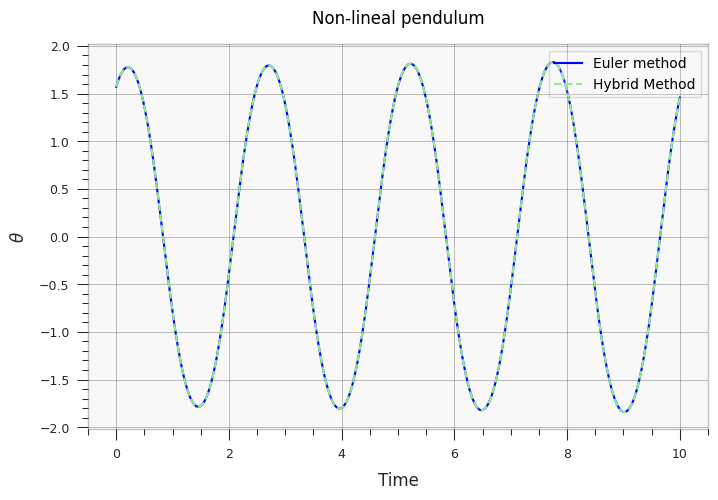

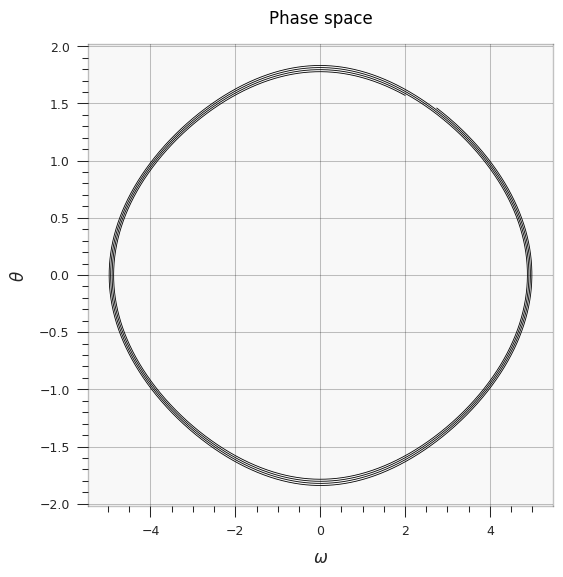

In [7]:
mpl_style(dark=False)

history_array = np.array(output_components_history)
x_pend_values = history_array[:, 0]  
y_pend_values = history_array[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(t_values, x_pend_values, label='Euler method', color='blue')
plt.plot(t_values[:-1], theta_values, '--', label='Hybrid Method', color='lightgreen')
# plt.plot(y_pend_values, label='Segunda componente')
plt.title('Non-lineal pendulum')
plt.xlabel('Time')
plt.ylabel(r'$\theta$')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(y_pend_values, x_pend_values, linewidth=0.6,color='black')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\theta$')
plt.title('Phase space')
plt.grid(True)
plt.show()


# Lorentz system

In [8]:
# --- Parameters and Constant Definitions ---
h = 0.01
sigma = 10
rho = 28
beta = 8/3

x0 = 1
y0 = 1
z0 = 1

t_final = 50
num_steps = int(t_final / h)
t_values = np.linspace(0, t_final, num_steps + 1)

A = np.array([[1-h*sigma, h*sigma, 0, 0, 0, 0, 0, 0],
              [h*rho, 1-h, 0, -h*rho, 0, 0, 0, 0],
              [0, 0, 1-h*beta, 0, h, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 0, 0, 1]])


# Define the initial state for the first iteration
current_state_vector = np.array([x0, y0, z0, x0*z0, x0*y0, 1, 1, 1], requires_grad=False)

# List to store the first three components of each output state
output_components_history = []
output_components_history.append(np.real(current_state_vector[:3]))

print(f"Starting simulation of {num_steps} iterations...\n")

for i in range(num_steps):
    # 1. Execute the circuit with the current state
    output_state_vector = my_evolution_step(A, current_state_vector)

    # 2. Update the non-linear components 
    next_state_vector = np.copy(output_state_vector)
    next_state_vector[3] = next_state_vector[0] * next_state_vector[2]
    next_state_vector[4] = next_state_vector[0] * next_state_vector[1]

    # 3. Store the first 3 components
    output_components = np.real(output_state_vector[:3])
    output_components_history.append(output_components)

    # 4. Update the output state to be the input for the next circuit
    current_state_vector = next_state_vector

    # Print the current state 
    if i % 1000 == 0:
        print(f"--- Iteration {i+1} ---")
        print(f"Circuit output state: {output_state_vector}")
        print("-" * 20)

    # print(f"--- Iteration {i+1} ---")
    # print(f"Circuit output state: {output_state_vector}")
    # print(f"Input state for the next step: {current_state_vector}")
    # print(f"Saved components in the history: {output_components}")
    # print("-" * 20)


Starting simulation of 5000 iterations...

--- Iteration 1 ---
Circuit output state: [1.        +0.j 0.99      +0.j 0.98333333+0.j 1.        +0.j
 1.        +0.j 1.        +0.j 1.        +0.j 1.        +0.j]
--------------------
--- Iteration 1001 ---
Circuit output state: [1.4295218 +0.j 2.03143169+0.j 0.74760717+0.j 1.01575577+0.j
 2.67632664+0.j 1.        +0.j 1.        +0.j 1.        +0.j]
--------------------
--- Iteration 2001 ---
Circuit output state: [-0.60083208+0.j -1.00169832+0.j  0.78663424+0.j -0.44833545+0.j
  0.54780761+0.j  1.        +0.j  1.        +0.j  1.        +0.j]
--------------------
--- Iteration 3001 ---
Circuit output state: [1.51350845+0.j 2.43306787+0.j 0.62671228+0.j 0.87015925+0.j
 3.28056388+0.j 1.        +0.j 1.        +0.j 1.        +0.j]
--------------------
--- Iteration 4001 ---
Circuit output state: [1.47683601+0.j 1.3662868 +0.j 0.96336681+0.j 1.44265686+0.j
 2.03547519+0.j 1.        +0.j 1.        +0.j 1.        +0.j]
--------------------


In [9]:
# Values storage
x_classic_values = []
y_classic_values = []
z_classic_values = []

# Current values
x, y, z = x0, y0, z0

Non_Linear = np.array([[-(1 - h * sigma), -h * sigma, 0, 1, 0, 0, 0, 0],
                       [-h * rho, -(1 - h), 0, 0, 1, 0, h, 0],
                       [0, 0, -(1 - beta * h), 0, 0, 1, 0, -h]])

# Matrix A for the system of equations
A = np.array(np.zeros((8, 8)))

A[0:3, 0:3] = np.identity(3)
A[3:6, 0:8] = Non_Linear
A[6:8, 6:8] = np.identity(2)


# Euler's method loop
for _ in range(num_steps):
  
    # Right-hand side vector
    b = np.array([x, y, z, 0, 0, 0, x * z, x * y])

    # Solve the linear system A * w = b
    w = np.linalg.solve(A, b)

    # Update current values
    x = w[3]
    y = w[4]
    z = w[5]

    # Extract new values
    x_classic_values.append(x)
    y_classic_values.append(y)
    z_classic_values.append(z)

C:\Users\User\AppData\Local\Temp\ipykernel_15800\496252980.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


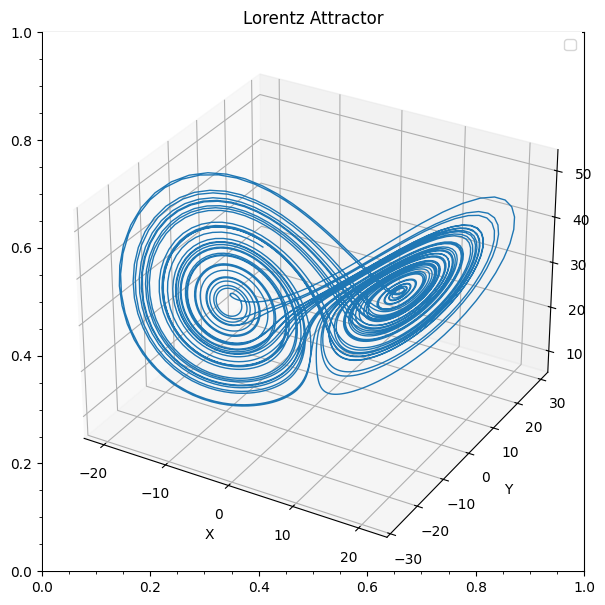

In [11]:
plt.style.use('default')

history_array = np.array(output_components_history)
x_values = history_array[:, 0]  
y_values = history_array[:, 1]
z_values = history_array[:, 2]

fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(111, projection='3d')

# ax.plot(x_values*5.78030754, y_values*5.96392868, z_values*30.38449617, linewidth=0.8, label='Euler Method')
ax.plot(x_values*5.78030754, y_values*5.96392868, z_values*30.38449617, linewidth=1)
# ax.plot(x_classic_values, y_classic_values, z_classic_values, linestyle='--', linewidth=0.5) 
ax.set_title('Lorentz Attractor')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.legend()
# ax.view_init(45, 135)

plt.show()